In [2]:
#Importing modules

%conda install seaborn -c conda-forge
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.607600000000093 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2             

## Data Preprocessing ##

In [5]:
#Reading employee dataset

data=pd.read_csv("ABC Company.xlsx - Sheet1.csv")

In [10]:
#Data frame creation
df=pd.DataFrame(data)
df


# Height data is inconsistent so replacing it with random numbers ranging from 150 to 180
df["Height"]=np.random.randint(150,181,len(df))
df



,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,166,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,158,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,180,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,164,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,178,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,176,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,159,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,176,231,Kansas,947276.0


## Data Exploration ##

In [11]:
# Data Summary
df.describe()


,Number,Age,Height,Weight,Salary
count,458.000000,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,165.004367,221.543668,4.833970e+06
std,15.966837,4.400128,8.957472,26.343200,5.226620e+06
min,0.000000,19.000000,150.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,157.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,165.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,173.000000,240.000000,6.500000e+06
max,99.000000,40.000000,180.000000,307.000000,2.500000e+07


In [12]:
# Checking for null values if any in he data set
null_values=df.isnull().sum()
null_values

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [15]:

print(df.shape)
#Shape reamins same after altering the height values, so data is good to proceed with.

(458, 9)


In [96]:
### Converting Team into num value ###

#unique values 
unique_teams = df['Team'].unique()
unique_teams


np.random.seed(42)  
random_numbers = np.random.choice(range(1, 31), size=len(unique_teams), replace=False)

# Create mapping
random_mapping = dict(zip(unique_teams, random_numbers))

# Apply mapping
df['Team_Num'] = df['Team'].map(random_mapping)

# Display results
print("Random Mapping:", random_mapping)
print(df)


df


Random Mapping: {'Boston Celtics': np.int32(28), 'Brooklyn Nets': np.int32(16), 'New York Knicks': np.int32(24), 'Philadelphia 76ers': np.int32(18), 'Toronto Raptors': np.int32(9), 'Golden State Warriors': np.int32(10), 'Los Angeles Clippers': np.int32(29), 'Los Angeles Lakers': np.int32(25), 'Phoenix Suns': np.int32(13), 'Sacramento Kings': np.int32(1), 'Chicago Bulls': np.int32(5), 'Cleveland Cavaliers': np.int32(17), 'Detroit Pistons': np.int32(6), 'Indiana Pacers': np.int32(14), 'Milwaukee Bucks': np.int32(12), 'Dallas Mavericks': np.int32(23), 'Houston Rockets': np.int32(2), 'Memphis Grizzlies': np.int32(3), 'New Orleans Pelicans': np.int32(26), 'San Antonio Spurs': np.int32(4), 'Atlanta Hawks': np.int32(22), 'Charlotte Hornets': np.int32(27), 'Miami Heat': np.int32(19), 'Orlando Magic': np.int32(30), 'Washington Wizards': np.int32(21), 'Denver Nuggets': np.int32(8), 'Minnesota Timberwolves': np.int32(11), 'Oklahoma City Thunder': np.int32(15), 'Portland Trail Blazers': np.int32(2

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Team_Num
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0,28
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0,28
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN,28
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0,28
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0,28
...,...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0,7
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0,7
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0,7
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0,7


In [97]:
team_counts = df['Team'].value_counts()
team_counts

df

unique_team_count = df['Position'].nunique()
unique_team_count


5

In [98]:
### Converting College into num value ###

#unique values 
unique_college = df['College'].unique()
unique_college


np.random.seed(42)  
random_numbers = np.random.choice(range(1, 120), size=len(unique_college), replace=False)

# Create mapping
random_mapping = dict(zip(unique_college, random_numbers))

# Apply mapping
df['College_Num'] = df['College'].map(random_mapping)

df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Team_Num,College_Num
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0,28,57
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0,28,90
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN,28,5
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0,28,46
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0,28,27
...,...,...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0,7,103
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0,7,27
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0,7,27
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0,7,65


In [99]:
### Converting Position into num value ###

#unique values 
unique_position = df['Position'].unique()
unique_position


np.random.seed(42)  
random_numbers = np.random.choice(range(1,6), size=len(unique_position), replace=False)

# Create mapping
random_mapping = dict(zip(unique_position, random_numbers))

# Apply mapping
df['Position_Num'] = df['Position'].map(random_mapping)

df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Team_Num,College_Num,Position_Num
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0,28,57,2
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0,28,90,5
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN,28,5,3
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0,28,46,3
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0,28,27,1
...,...,...,...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0,7,103,2
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0,7,27,2
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0,7,27,4
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0,7,65,4


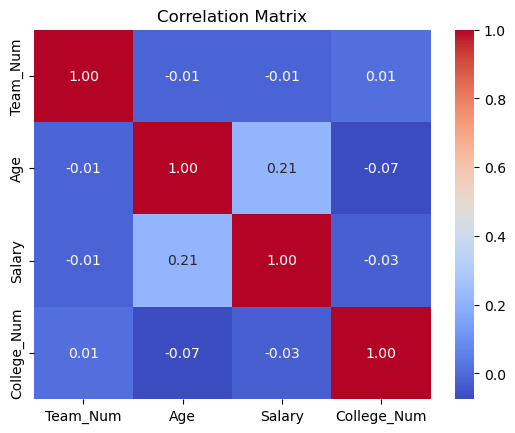

In [100]:
cols = ['Team_Num','Age','Salary','College_Num',]
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## BOX PLOT ##


To find the distribution of employees in each team and perecentage split relative to total employees

Distribution of employees across each team 
 Team
New Orleans Pelicans      19
Memphis Grizzlies         18
New York Knicks           16
Milwaukee Bucks           16
Utah Jazz                 16
Boston Celtics            15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Chicago Bulls             15
Cleveland Cavaliers       15
Detroit Pistons           15
Indiana Pacers            15
Dallas Mavericks          15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Charlotte Hornets         15
Miami Heat                15
Washington Wizards        15
Denver Nuggets            15
Oklahoma City Thunder     15
Portland Trail Blazers    15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64


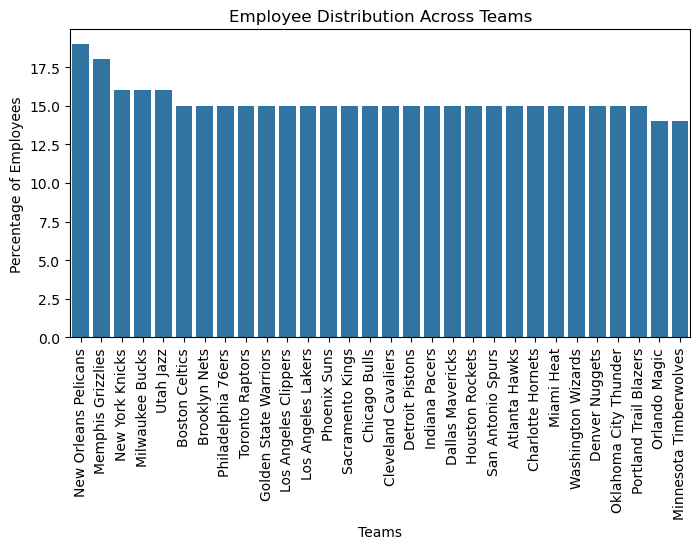

In [101]:
#Team Distribution
Team_Count =df['Team'].value_counts()
print("Distribution of employees across each team \n",Team_Count)

Total_pop=len(df)

#Calculating relative percentage
Percentage=(Team_Count/Total_pop)*100

#Visualisation
plt.figure(figsize=(8, 4))
sns.barplot(x=Team_Count.index, y=Team_Count.values)
plt.xlabel("Teams")
plt.ylabel("Percentage of Employees")
plt.title("Employee Distribution Across Teams")
plt.xticks(rotation=90)
plt.show()

## Findings ##

## PIE CHART ##

Segregate employees based on their positions within the company

In [ ]:
# To differentiate the positions of employees within the company

Different positions within company
 Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


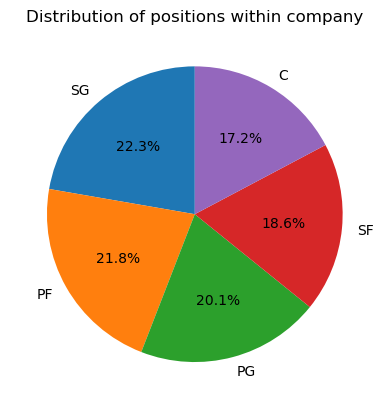

In [105]:
#Different Position and their counts
Position_counts =df['Position'].value_counts()
print("Different positions within company\n",Position_counts)

#Visualisation
plt.pie(Position_counts, labels=Position_counts.index, autopct='%1.1f%%',
         startangle=90)
plt.title('Distribution of positions within company')
plt.show()

### Findings ###

In [ ]:
# Position SG contributes 22.3% which the highest among all the positions in the company.
# That is , out of 100% of employees 22.3% are having the position SG

#And C is the least with 17.2%

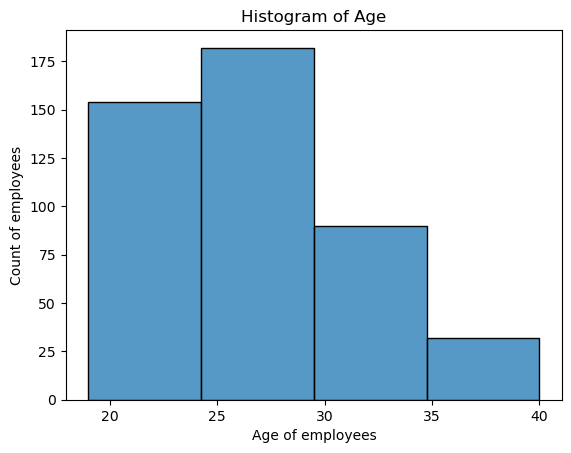

In [33]:

#Visualisation

sns.histplot(data=df,x="Age",bins=4,multiple="dodge")

plt.title("Histogram of Age")
plt.xlabel("Age of employees")
plt.ylabel("Count of employees")
plt.show()